# Classical Fraud Models

This notebook adds a classical-model mode to the existing fraud-detection pipeline.

It uses the same three feature datasets produced by the repository:

1. `fraud_preprocessing/fraud_prepared_numeric.csv`
2. `wrapper/fraud_selected_features_rfecv.csv`
3. `PCA/fraud_pca_95_variance.csv`

Each dataset is trained and evaluated with Linear Regression style Keras output, Decision Tree, Random Forest, and XGBoost.

In [1]:

import os
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebook" else Path.cwd()
MODEL_DIR = ROOT / "model" / "Classical"
CSV_DIR = MODEL_DIR / "csv"
FIG_DIR = MODEL_DIR / "figure"
for folder in [MODEL_DIR, CSV_DIR, FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

DATASETS = {
    "fraud_prepared_numeric": ROOT / "fraud_preprocessing" / "fraud_prepared_numeric.csv",
    "fraud_selected_features_rfecv": ROOT / "wrapper" / "fraud_selected_features_rfecv.csv",
    "fraud_pca_95_variance": ROOT / "PCA" / "fraud_pca_95_variance.csv",
}

TARGET_COL = "fraud"


## Model Architectures

- **Linear Regression (Keras):** `Input(n_features) -> Dense(1, sigmoid)`. This is the linear fraud-probability baseline used for the binary target.
- **Decision Tree:** one CART classifier with class balancing and depth controls.
- **Random Forest:** bagged CART ensemble with balanced class weights.
- **XGBoost:** gradient-boosted tree ensemble with imbalance-aware positive-class weighting.

All models use the same train/validation/test split for each feature dataset. The validation split chooses the decision threshold that maximizes F1-score, and the final scores are reported on the held-out test split.

In [2]:

def load_dataset(path):
    df = pd.read_csv(path)
    if TARGET_COL not in df.columns:
        raise ValueError(f"Missing target column: {TARGET_COL}")

    X = df.drop(columns=[TARGET_COL]).copy()
    y = df[TARGET_COL].astype(int).copy()

    for col in X.columns:
        if X[col].isna().any():
            X[col] = X[col].fillna(X[col].median())

    return X, y


def split_and_scale(X, y):
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=SEED
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.20, stratify=y_train_full, random_state=SEED
    )

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)

    return X_train_s, X_val_s, X_test_s, y_train.to_numpy(), y_val.to_numpy(), y_test.to_numpy(), scaler


def class_weights(y_train):
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    return {int(c): float(w) for c, w in zip(classes, weights)}


def best_threshold(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.50
    f1 = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    return float(thresholds[int(np.nanargmax(f1))])


def score_predictions(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "threshold": threshold,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


In [3]:

def build_linear_regression(input_dim):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(1, activation="sigmoid", name="fraud_probability"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="roc_auc"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
        ],
    )
    return model


def tree_models(y_train):
    negatives = max(int((y_train == 0).sum()), 1)
    positives = max(int((y_train == 1).sum()), 1)
    return {
        "decision_tree": (
            "Decision Tree",
            DecisionTreeClassifier(
                max_depth=12,
                min_samples_leaf=40,
                class_weight="balanced",
                random_state=SEED,
            ),
        ),
        "random_forest": (
            "Random Forest",
            RandomForestClassifier(
                n_estimators=60,
                max_depth=12,
                min_samples_leaf=20,
                class_weight="balanced",
                n_jobs=-1,
                random_state=SEED,
            ),
        ),
        "xgboost": (
            "XGBoost",
            XGBClassifier(
                n_estimators=120,
                max_depth=4,
                learning_rate=0.08,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                scale_pos_weight=negatives / positives,
                n_jobs=-1,
                random_state=SEED,
            ),
        ),
    }


In [4]:

def train_linear(dataset_name, X_train, X_val, X_test, y_train, y_val, y_test):
    model = build_linear_regression(X_train.shape[1])
    history = model.fit(
        X_train.astype("float32"),
        y_train,
        validation_data=(X_val.astype("float32"), y_val),
        epochs=30,
        batch_size=256,
        class_weight=class_weights(y_train),
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor="val_pr_auc", mode="max", patience=5, restore_best_weights=True
            )
        ],
        verbose=0,
    )

    val_prob = model.predict(X_val.astype("float32"), verbose=0).ravel()
    test_prob = model.predict(X_test.astype("float32"), verbose=0).ravel()
    threshold = best_threshold(y_val, val_prob)

    pd.DataFrame(history.history).to_csv(CSV_DIR / f"{dataset_name}_linear_regression_history.csv", index=False)
    model.save(MODEL_DIR / f"{dataset_name}_linear_regression_model.keras")

    return "Linear Regression", test_prob, score_predictions(y_test, test_prob, threshold)


def train_tree_model(dataset_name, model_slug, model_label, model, X_train, X_val, X_test, y_train, y_val, y_test):
    model.fit(X_train, y_train)
    val_prob = model.predict_proba(X_val)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]
    threshold = best_threshold(y_val, val_prob)

    joblib.dump(model, MODEL_DIR / f"{dataset_name}_{model_slug}_model.joblib")
    return model_label, test_prob, score_predictions(y_test, test_prob, threshold)


In [5]:

def plot_confusions(dataset_name, rows):
    fig, axes = plt.subplots(2, 2, figsize=(8, 7))
    for ax, row in zip(axes.ravel(), rows):
        cm = np.array([[row["tn"], row["fp"]], [row["fn"], row["tp"]]])
        ax.imshow(cm, cmap="Blues")
        ax.set_title(row["model"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        for i in range(2):
            for j in range(2):
                ax.text(j, i, int(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{dataset_name}_classical_confusion_matrices.png", dpi=160)
    plt.show()


def plot_curves(dataset_name, y_test, probabilities):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for label, prob in probabilities.items():
        precision, recall, _ = precision_recall_curve(y_test, prob)
        fpr, tpr, _ = roc_curve(y_test, prob)
        axes[0].plot(recall, precision, label=label)
        axes[1].plot(fpr, tpr, label=label)

    axes[0].set_title(f"{dataset_name}: PR curves")
    axes[0].set_xlabel("Recall")
    axes[0].set_ylabel("Precision")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    axes[1].set_title(f"{dataset_name}: ROC curves")
    axes[1].set_xlabel("False positive rate")
    axes[1].set_ylabel("True positive rate")
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{dataset_name}_classical_roc_pr_curves.png", dpi=160)
    plt.show()


def plot_metric_comparison(results_df):
    labels = results_df["dataset"].str.replace("fraud_", "", regex=False) + "\n" + results_df["model"]
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    axes[0].bar(labels, results_df["f1"])
    axes[0].set_ylabel("F1-score")
    axes[0].grid(axis="y", alpha=0.25)
    axes[1].bar(labels, results_df["pr_auc"])
    axes[1].set_ylabel("PR-AUC")
    axes[1].grid(axis="y", alpha=0.25)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "classical_metrics_comparison.png", dpi=160)
    plt.show()


DATASET: fraud_prepared_numeric


Rows: 180,519 | Features: 55 | Fraud rate: 0.0225


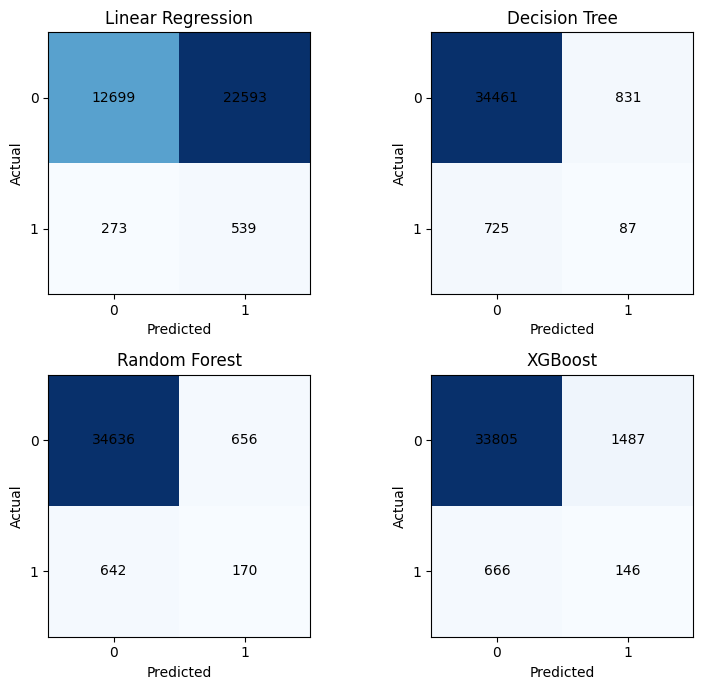

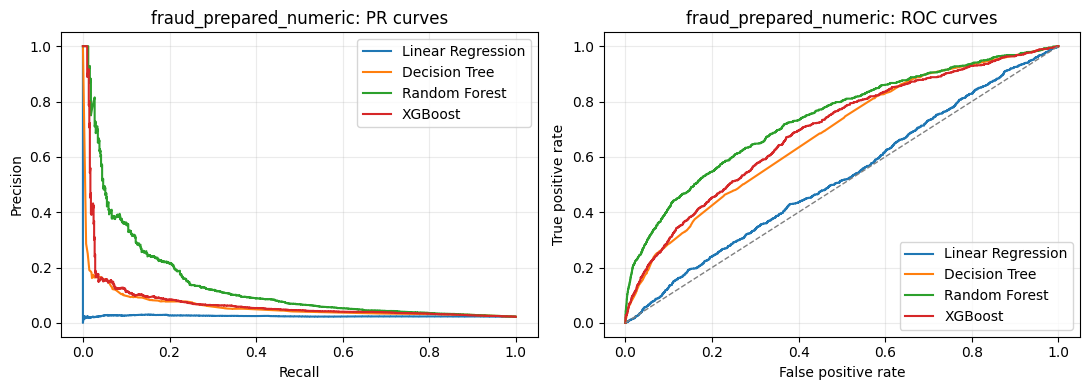

DATASET: fraud_selected_features_rfecv


Rows: 180,519 | Features: 17 | Fraud rate: 0.0225


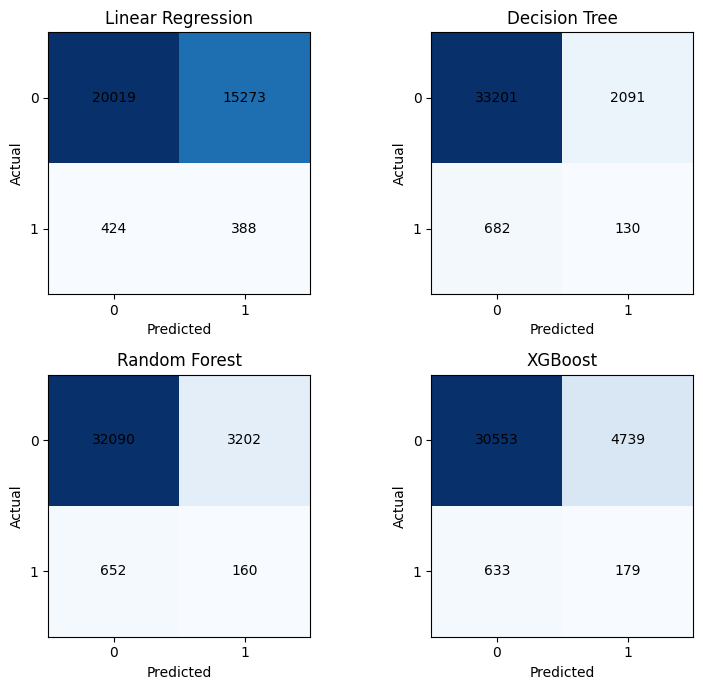

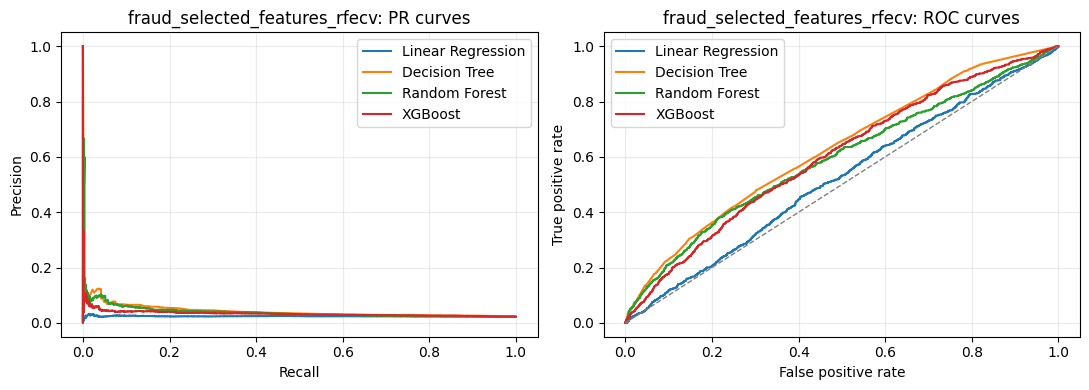

DATASET: fraud_pca_95_variance


Rows: 180,519 | Features: 11 | Fraud rate: 0.0225


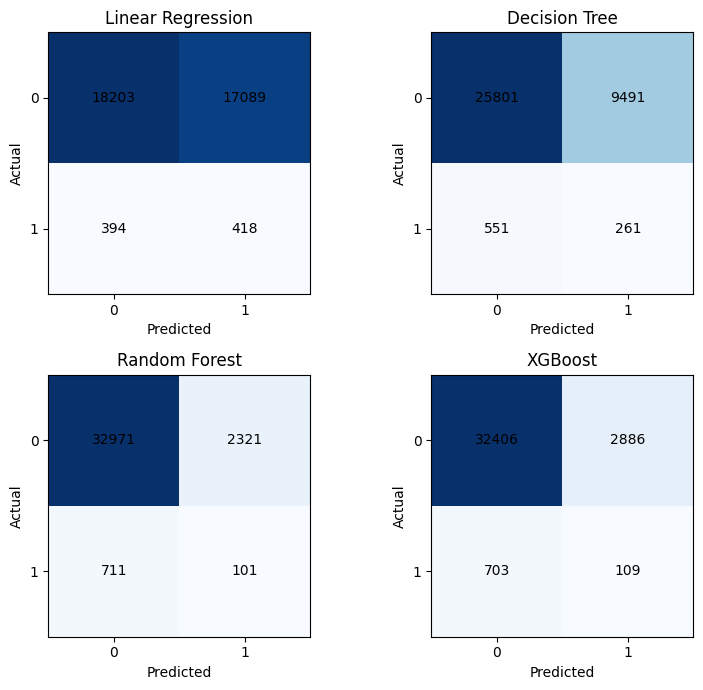

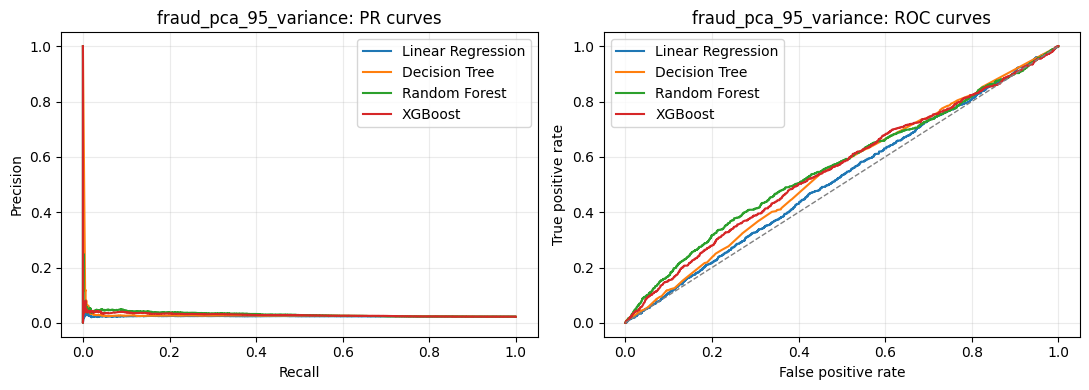

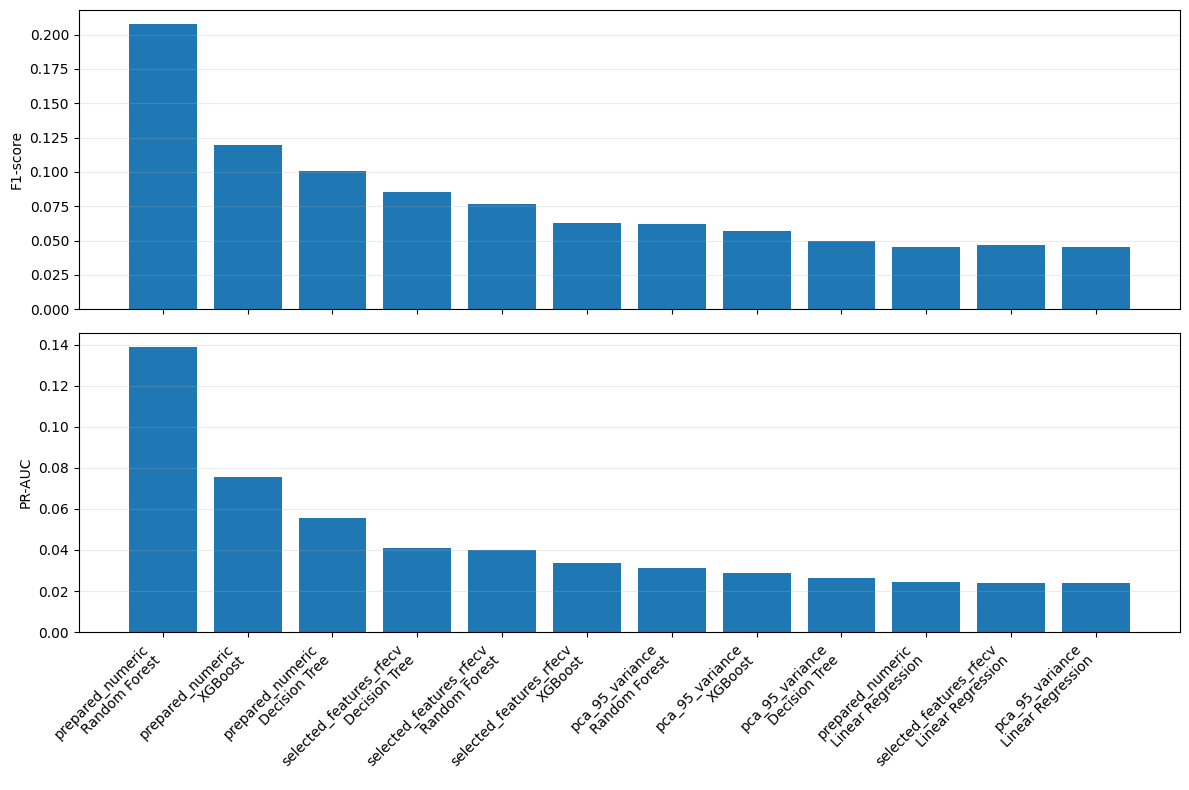

,dataset,model,features,accuracy,precision,recall,f1,roc_auc,pr_auc,threshold,tn,fp,fn,tp
2,fraud_prepared_numeric,Random Forest,55,0.964048,0.205811,0.209360,0.207570,0.740321,0.138930,0.511860,34636,656,642,170
3,fraud_prepared_numeric,XGBoost,55,0.940367,0.089406,0.179803,0.119427,0.694523,0.075580,0.583103,33805,1487,666,146
1,fraud_prepared_numeric,Decision Tree,55,0.956902,0.094771,0.107143,0.100578,0.678514,0.055735,0.816914,34461,831,725,87
5,fraud_selected_features_rfecv,Decision Tree,17,0.923194,0.058532,0.160099,0.085724,0.627677,0.040763,0.695685,33201,2091,682,130
6,fraud_selected_features_rfecv,Random Forest,17,0.893253,0.047591,0.197044,0.076665,0.593344,0.039951,0.527864,32090,3202,652,160
7,fraud_selected_features_rfecv,XGBoost,17,0.851208,0.036397,0.220443,0.062478,0.601524,0.033712,0.545485,30553,4739,633,179
10,fraud_pca_95_variance,Random Forest,11,0.916020,0.041701,0.124384,0.062461,0.563252,0.031287,0.549150,32971,2321,711,101
11,fraud_pca_95_variance,XGBoost,11,0.900593,0.036394,0.134236,0.057263,0.555458,0.028751,0.578081,32406,2886,703,109
9,fraud_pca_95_variance,Decision Tree,11,0.721859,0.026764,0.321429,0.049413,0.542019,0.026347,0.571862,25801,9491,551,261
0,fraud_prepared_numeric,Linear Regression,55,0.366663,0.023301,0.663793,0.045022,0.524977,0.024550,0.479274,12699,22593,273,539


In [6]:

all_results = []

for dataset_name, dataset_path in DATASETS.items():
    print("=" * 80)
    print(f"DATASET: {dataset_name}")

    X, y = load_dataset(dataset_path)
    X_train, X_val, X_test, y_train, y_val, y_test, scaler = split_and_scale(X, y)
    joblib.dump(scaler, MODEL_DIR / f"{dataset_name}_scaler.joblib")

    print(f"Rows: {len(y):,} | Features: {X.shape[1]} | Fraud rate: {y.mean():.4f}")

    dataset_rows = []
    probabilities = {}
    predictions = pd.DataFrame({"y_true": y_test})

    model_label, test_prob, metrics = train_linear(dataset_name, X_train, X_val, X_test, y_train, y_val, y_test)
    row = {"dataset": dataset_name, "model": model_label, "features": X.shape[1], **metrics}
    dataset_rows.append(row)
    probabilities[model_label] = test_prob
    predictions["linear_regression_probability"] = test_prob
    predictions["linear_regression_prediction"] = (test_prob >= metrics["threshold"]).astype(int)

    for model_slug, (model_label, model) in tree_models(y_train).items():
        model_label, test_prob, metrics = train_tree_model(
            dataset_name, model_slug, model_label, model, X_train, X_val, X_test, y_train, y_val, y_test
        )
        row = {"dataset": dataset_name, "model": model_label, "features": X.shape[1], **metrics}
        dataset_rows.append(row)
        probabilities[model_label] = test_prob
        predictions[f"{model_slug}_probability"] = test_prob
        predictions[f"{model_slug}_prediction"] = (test_prob >= metrics["threshold"]).astype(int)

    predictions.to_csv(CSV_DIR / f"{dataset_name}_classical_test_predictions.csv", index=False)
    plot_confusions(dataset_name, dataset_rows)
    plot_curves(dataset_name, y_test, probabilities)
    all_results.extend(dataset_rows)

results_df = pd.DataFrame(all_results).sort_values("pr_auc", ascending=False)
results_df.to_csv(CSV_DIR / "classical_results_comparison.csv", index=False)
plot_metric_comparison(results_df)

display(results_df)


## Output Files

The trained models and evaluation artifacts are saved under `model/Classical/`:

- `*_linear_regression_model.keras`
- `*_decision_tree_model.joblib`
- `*_random_forest_model.joblib`
- `*_xgboost_model.joblib`
- `csv/classical_results_comparison.csv`
- `csv/*_classical_test_predictions.csv`
- `figure/*_classical_confusion_matrices.png`
- `figure/*_classical_roc_pr_curves.png`
- `figure/classical_metrics_comparison.png`